# FINA 4713 – Final Project
## Machine Learning for Cross-Sectional Stock Return Prediction

**Introduction to AI and Big Data in Finance — Spring 2026**

Full pipeline: preprocessing → IC screening → Grouped PCA → Ridge/OLS (expanding window) → GKX NN3 (static, 3 input configs) → evaluation.

| Split | Period | Purpose |
|-------|--------|---------|
| Training   | Jan 2005 – Dec 2015 | Fit preprocessors, IC screening, PCA, model coefficients |
| Validation | Jan 2016 – Dec 2018 | Ridge λ selection only; never used for test evaluation |
| Test       | Jan 2019 – Dec 2024 | All reported out-of-sample metrics |

## Setup

In [5]:
import warnings; warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw): return it

## Constants & Shared Helper Functions

In [6]:
TARGET    = 'ret_exc_lead1m'
TRAIN_END = '2015-12-31'
VAL_END   = '2018-12-31'
META      = ['id', 'eom', 'excntry', TARGET, 'me']
MIN_STOCKS_PER_MONTH = 20


def fit_preprocessor(X_df):
    """Fit winsorisation bounds, median imputer, and z-score scaler on X_df."""
    low  = X_df.quantile(0.01)
    high = X_df.quantile(0.99)
    X_clipped = X_df.clip(lower=low, upper=high, axis=1)
    imp = SimpleImputer(strategy='median').fit(X_clipped)
    sc  = StandardScaler().fit(imp.transform(X_clipped))
    return low, high, imp, sc


def apply_preprocessor(X_df, low, high, imp, sc):
    """Apply pre-fitted preprocessor — no parameters are re-estimated here."""
    X = X_df.clip(lower=low, upper=high, axis=1)
    X = imp.transform(X)
    return sc.transform(X)


def apply_signed_log1p(df_in, log_feats):
    """sign(x)*log1p(|x|) — monotone, so Spearman IC is invariant."""
    df_out = df_in.copy()
    present = [f for f in log_feats if f in df_out.columns]
    if present:
        X = df_out[present].apply(pd.to_numeric, errors='coerce')
        df_out[present] = np.sign(X) * np.log1p(np.abs(X))
    return df_out


def portfolio_weights(pred, max_w=0.05):
    """Rank-based dollar-neutral long-short weights, capped at max_w per stock."""
    n  = len(pred)
    w  = pd.Series(pred).rank() - (n + 1) / 2
    w /= w.abs().sum()
    w  = w.clip(-max_w, max_w)
    w /= w.abs().sum()
    return w.values


def oos_r2(y_true, y_pred, y_null):
    """OOS R² relative to the historical-average null (Campbell & Thompson 2008)."""
    return 1 - np.mean((y_true - y_pred)**2) / np.mean((y_true - y_null)**2)


def compute_turnover(df_results, pred_col, id_col='id'):
    """Average one-way monthly portfolio turnover, annualised."""
    prev_w = {}
    monthly_to = []
    for _, grp in df_results.groupby('eom'):
        ids   = grp[id_col].values
        w     = portfolio_weights(grp[pred_col].values)
        new_w = dict(zip(ids.tolist(), w.tolist()))
        if prev_w:
            all_ids = set(prev_w) | set(new_w)
            monthly_to.append(
                sum(abs(new_w.get(s, 0.0) - prev_w.get(s, 0.0)) for s in all_ids) / 2
            )
        prev_w = new_w
    return float(np.mean(monthly_to) * 12) if monthly_to else float('nan')

In [7]:
FEATURE_GROUPS = {
    'momentum': [
        'ret_2_0', 'ret_3_0', 'ret_3_1', 'ret_6_0', 'ret_6_1',
        'ret_9_0', 'ret_9_1', 'ret_12_0', 'ret_12_1', 'ret_12_7',
        'ret_18_1', 'ret_24_1', 'ret_24_12', 'ret_36_1', 'ret_36_12',
        'ret_48_1', 'ret_48_12', 'ret_60_1', 'ret_60_12', 'ret_60_36',
        'resff3_6_1', 'resff3_12_1',
    ],
    'short_term_reversal': ['ret_1_0'],
    'seasonality': [
        'seas_1_1an', 'seas_1_1na', 'seas_2_5an', 'seas_2_5na',
        'seas_6_10an', 'seas_6_10na',
    ],
    'value': [
        'be_me', 'at_me', 'sale_me', 'ni_me', 'ocf_me', 'fcf_me',
        'ebitda_mev', 'bev_mev', 'eq_dur', 'ival_me', 'div12m_me',
        'eqpo_me', 'eqnpo_me', 'ebit_bev', 'cash_me', 'netis_mev', 'log_me',
    ],
    'profitability': [
        'gp_at', 'ope_be', 'ni_be', 'cop_at', 'op_at', 'ocf_at',
        'ebit_sale', 'gp_atl1', 'ope_bel1', 'cop_atl1', 'niq_be',
        'niq_at', 'pi_nix', 'op_atl1', 'ocf_at_chg1', 'niq_be_chg1',
    ],
    'profit_growth': [
        'gpoa_ch5', 'roe_ch5', 'roa_ch5', 'cfoa_ch5', 'gmar_ch5',
        'niq_su', 'ocfq_saleq_std', 'niq_saleq_std', 'roe_be_std',
        'dsale_dinv', 'dsale_drec', 'dgp_dsale', 'dsale_dsga',
        'ni_inc8q', 'niq_at_chg1',
    ],
    'investment': [
        'at_gr1', 'sale_gr1', 'capx_gr1', 'inv_gr1', 'noa_gr1a',
        'ppeinv_gr1a', 'lnoa_gr1a', 'sale_gr3', 'capx_gr3', 'capx_gr2',
        'inv_gr1a', 'be_gr1a', 'emp_gr1', 'saleq_gr1', 'capex_abn',
        'sti_gr1a', 'capx_gr3a', 'lti_gr1a',
    ],
    'accruals': [
        'oaccruals_at', 'taccruals_at', 'oaccruals_ni', 'taccruals_ni',
        'cowc_gr1a', 'ncoa_gr1a', 'ncol_gr1a', 'nncoa_gr1a',
        'coa_gr1a', 'col_gr1a', 'tax_gr1a', 'nfna_gr1a', 'fnl_gr1a', 'noa_at',
    ],
    'debt_issuance': [
        'chcsho_12m', 'eqnpo_12m', 'netis_at', 'eqnetis_at', 'dbnetis_at',
        'eqnpo_1m', 'eqnpo_3m', 'eqnpo_6m', 'div3m_me', 'div6m_me',
        'chcsho_1m', 'chcsho_3m', 'chcsho_6m', 'debt_gr3',
    ],
    'leverage': ['at_be', 'debt_me', 'netdebt_me', 'at_turnover', 'sale_bev', 'opex_at'],
    'low_risk': [
        'beta_60m', 'ivol_capm_21d', 'ivol_ff3_21d', 'ivol_capm_252d',
        'ivol_capm_60m', 'rvol_21d', 'rvol_252d', 'rmax1_21d', 'rmax5_21d',
        'betabab_1260d', 'coskew_21d', 'betadown_252d', 'iskew_capm_21d',
        'iskew_ff3_21d', 'iskew_hxz4_21d', 'ivol_hxz4_21d', 'beta_21d',
        'beta_252d', 'rmax5_rvol_21d', 'corr_1260d', 'beta_dimson_21d',
        'rvolhl_21d', 'rskew_21d',
    ],
    'quality': [
        'qmj', 'qmj_prof', 'qmj_growth', 'qmj_safety', 'f_score',
        'o_score', 'z_score', 'kz_index', 'ni_ar1', 'ni_ivol',
        'earnings_variability', 'tangibility', 'aliq_at', 'aliq_mat',
        'mispricing_mgmt', 'mispricing_perf',
    ],
    'size_liquidity': [
        'dolvol', 'dolvol_126d', 'dolvol_var_126d', 'turnover_126d',
        'turnover_var_126d', 'zero_trades_21d', 'zero_trades_126d',
        'zero_trades_252d', 'ami_126d', 'bidaskhl_21d', 'prc_highprc_252d',
        'bidask', 'tvol',
    ],
    'other': ['cash_at', 'age', 'sale_emp', 'sale_emp_gr1'],
}


class GroupedPCA:
    """Independent PCA within each JKP economic theme group (90% variance per group)."""
    def __init__(self, groups, var_threshold=0.90):
        self.groups = groups
        self.var_threshold = var_threshold
        self.fitted = {}
        self.output_names = []

    def fit(self, X_df):
        self.fitted = {}; self.output_names = []
        for grp, feats in self.groups.items():
            avail = [f for f in feats if f in X_df.columns]
            if len(avail) == 0:
                continue
            if len(avail) == 1:
                self.fitted[grp] = (avail, None)
                self.output_names.append(f'{grp}_F1')
                continue
            Xg = X_df[avail].values
            pca_full = PCA(n_components=min(len(avail), Xg.shape[0] - 1)).fit(Xg)
            cumvar = np.cumsum(pca_full.explained_variance_ratio_)
            n_comp = int(np.searchsorted(cumvar, self.var_threshold)) + 1
            n_comp = max(1, min(n_comp, len(avail)))
            pca = PCA(n_components=n_comp).fit(Xg)
            self.fitted[grp] = (avail, pca)
            for i in range(n_comp):
                self.output_names.append(f'{grp}_PC{i+1}')
        return self

    def transform(self, X_df):
        parts = []
        for grp, (feats, pca) in self.fitted.items():
            avail = [f for f in feats if f in X_df.columns]
            Xg = X_df[avail].values if avail else np.zeros((len(X_df), len(feats)))
            parts.append(Xg if pca is None else pca.transform(Xg))
        return np.hstack(parts) if parts else np.zeros((len(X_df), 0))

    def fit_transform(self, X_df):
        return self.fit(X_df).transform(X_df)

## 1. Load Data

Source: Jensen, Kelly & Pedersen (2023) dataset. ~3M stock-month observations across 10 countries, 2005–2024.
Target: `ret_exc_lead1m` — forward 1-month excess stock return.

In [8]:
print('Loading parquet...')
df = pd.read_parquet('./jkp_data.parquet')
print(f'  Shape : {df.shape}')
print(f'  Period: {df["eom"].min().date()} to {df["eom"].max().date()}')
print(f'  Firms : {df["id"].nunique():,}')

# Log-transform market equity (right-skewed by construction)
df['log_me'] = np.log1p(df['me'].clip(lower=0))

# All numeric characteristics + log_me, minus metadata columns
FEATURES = list(dict.fromkeys([c for c in df.columns if c not in META] + ['log_me']))

# Drop rows with missing target — cannot be used for training or evaluation
df = df.dropna(subset=[TARGET])

# Temporal splits — dates are uniform across all groups; do not change
train = df[df['eom'] <= TRAIN_END]
val   = df[(df['eom'] > TRAIN_END) & (df['eom'] <= VAL_END)]
test  = df[df['eom'] > VAL_END]

print(f'\nTrain : {len(train):>7,} obs  ({train["eom"].min().date()} - {train["eom"].max().date()})')
print(f'Val   : {len(val):>7,} obs  ({val["eom"].min().date()} - {val["eom"].max().date()})')
print(f'Test  : {len(test):>7,} obs  ({test["eom"].min().date()} - {test["eom"].max().date()})')
print(f'Features: {len(FEATURES)}')

Loading parquet...
  Shape : (3096206, 201)
  Period: 2005-01-31 to 2024-12-31
  Firms : 38,009

Train : 1,570,926 obs  (2005-01-31 - 2015-12-31)
Val   : 458,210 obs  (2016-01-31 - 2018-12-31)
Test  : 973,847 obs  (2019-01-31 - 2024-11-30)
Features: 197


## 2. Selective Log-Transform

For any feature whose training-set absolute skewness exceeds 1.0, apply
$x \mapsto \mathrm{sign}(x) \cdot \log(1+|x|)$.
This is strictly monotone, so Spearman IC values are unchanged.
All skewness statistics are computed on the training set only.

In [9]:
SKEW_THRESHOLD = 1.0
train_skew  = train[FEATURES].apply(pd.to_numeric, errors='coerce').skew()
LOG_FEATURES = train_skew[train_skew.abs() > SKEW_THRESHOLD].index.tolist()
print(f'Log-transform: {len(LOG_FEATURES)}/{len(FEATURES)} features (|skew| > {SKEW_THRESHOLD})')

df    = apply_signed_log1p(df, LOG_FEATURES)
train = df[df['eom'] <= TRAIN_END]
val   = df[(df['eom'] > TRAIN_END) & (df['eom'] <= VAL_END)]
test  = df[df['eom'] > VAL_END]

Log-transform: 181/197 features (|skew| > 1.0)


## 3. IC Screening

For each feature, compute the monthly cross-sectional Spearman rank correlation (IC) with the
forward return over the 132 training months. Retain features with $|t\text{-stat}| \geq 1.5$.
All IC statistics are computed on training data only — no look-ahead.

In [10]:
IC_THRESHOLD = 1.5


def compute_ic_matrix(df_split, feats):
    df_num = df_split[feats + [TARGET]].apply(pd.to_numeric, errors='coerce').reset_index(drop=True)
    df_num['eom'] = df_split['eom'].values
    rows = []
    for _, grp in df_num.groupby('eom'):
        y = grp[TARGET].values
        row = []
        for f in feats:
            x = grp[f].values
            valid = ~np.isnan(x) & ~np.isnan(y)
            if valid.sum() >= 50:
                xv = x[valid]; yv = y[valid]
                xr = xv.argsort().argsort().astype(float)
                yr = yv.argsort().argsort().astype(float)
                xr -= xr.mean(); yr -= yr.mean()
                denom = np.sqrt((xr**2).sum() * (yr**2).sum())
                row.append(float(np.dot(xr, yr) / denom) if denom > 0 else 0.0)
            else:
                row.append(np.nan)
        rows.append(row)
    return pd.DataFrame(rows, columns=feats)


print('Computing monthly Spearman IC on training data...')
ic_mat   = compute_ic_matrix(train, FEATURES)
mean_ic  = ic_mat.mean()
std_ic   = ic_mat.std()
T_ic     = ic_mat.notna().sum()
ic_tstat = mean_ic / std_ic * np.sqrt(T_ic)

IC_FEATURES = ic_tstat[ic_tstat.abs() >= IC_THRESHOLD].index.tolist()
print(f'  IC screening: {len(FEATURES)} -> {len(IC_FEATURES)} kept  (|t| >= {IC_THRESHOLD})')
del ic_mat  # free memory

Computing monthly Spearman IC on training data...
  IC screening: 197 -> 144 kept  (|t| >= 1.5)


## 4. Preprocessing + Grouped PCA

**Preprocessing** (fit on training only, applied forward):
1. Winsorise at training 1st/99th percentiles
2. Median impute missing values
3. Z-score standardise

**Grouped PCA**: independent PCA within each of 14 JKP economic theme groups,
retaining components that explain ≥90% of within-group variance.
Reduces 140 IC-screened features to ~82 orthogonal components.

Pre-PCA matrices (`X_tr_ic`, `X_val_ic`, `X_te_ic`) are retained for ablation B.

In [11]:
to_num_ic = lambda d: d[IC_FEATURES].apply(pd.to_numeric, errors='coerce')

print('Fitting preprocessor on IC-screened features...')
low_ic, high_ic, imp_ic, sc_ic = fit_preprocessor(to_num_ic(train))

X_tr_ic  = apply_preprocessor(to_num_ic(train), low_ic, high_ic, imp_ic, sc_ic)
X_val_ic = apply_preprocessor(to_num_ic(val),   low_ic, high_ic, imp_ic, sc_ic)
X_te_ic  = apply_preprocessor(to_num_ic(test),  low_ic, high_ic, imp_ic, sc_ic)

print('Fitting Grouped PCA...')
gpca = GroupedPCA(FEATURE_GROUPS, var_threshold=0.90)
X_tr_pca  = gpca.fit_transform(pd.DataFrame(X_tr_ic,  columns=IC_FEATURES))
X_val_pca = gpca.transform(pd.DataFrame(X_val_ic, columns=IC_FEATURES))
X_te_pca  = gpca.transform(pd.DataFrame(X_te_ic,  columns=IC_FEATURES))

print(f'  Raw features : {len(FEATURES)}')
print(f'  After IC     : {len(IC_FEATURES)}')
print(f'  After PCA    : {X_tr_pca.shape[1]} components')
print(f'  X_train: {X_tr_pca.shape}  X_val: {X_val_pca.shape}  X_test: {X_te_pca.shape}')

y_tr  = train[TARGET].values
y_val = val[TARGET].values
y_te  = test[TARGET].values
hist_avg = y_tr.mean()

print(f'\nTraining mean return (hist_avg): {hist_avg:.5f}')
print(f'Historical-average val  R2: {oos_r2(y_val, np.full(len(y_val), hist_avg), np.full(len(y_val), hist_avg)):+.4f}  (always 0.0)')
print(f'Historical-average test R2: {oos_r2(y_te,  np.full(len(y_te),  hist_avg), np.full(len(y_te),  hist_avg)):+.4f}  (always 0.0)')

Fitting preprocessor on IC-screened features...
Fitting Grouped PCA...
  Raw features : 197
  After IC     : 144
  After PCA    : 81 components
  X_train: (1570926, 81)  X_val: (458210, 81)  X_test: (973847, 81)

Training mean return (hist_avg): 0.00441
Historical-average val  R2: +0.0000  (always 0.0)
Historical-average test R2: +0.0000  (always 0.0)


## 5. Ridge Regression

### 5a. Penalty (λ) Selection — Validation Set Only

Search over a log-spaced grid of the regularisation parameter λ.
For each candidate, train Ridge on the 2005–2015 training set and evaluate the implied
long–short portfolio **Sharpe ratio** on the 2016–2018 validation set.
The test set is **never touched** at this stage.

In [12]:
alpha_grid = [1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8]

val_eval = val[['eom', TARGET]].copy().reset_index(drop=True)
val_metrics = {}

print(f'{"Lambda":>10} | {"Val Sharpe":>10} | {"Val Ann. Ret":>12}')
print('-' * 38)

for alpha in alpha_grid:
    m = Ridge(alpha=alpha).fit(X_tr_pca, y_tr)
    val_eval['ridge_pred'] = m.predict(X_val_pca)
    monthly = []
    for _, grp in val_eval.groupby('eom'):
        w = portfolio_weights(grp['ridge_pred'].values)
        monthly.append((w * grp[TARGET].values).sum())
    pf_val = pd.Series(monthly)
    ann_ret = pf_val.mean() * 12
    ann_vol = pf_val.std() * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0.0
    val_metrics[alpha] = sharpe
    print(f'{alpha:>10.0f} | {sharpe:>10.4f} | {ann_ret:>12.2%}')

best_alpha = max(val_metrics, key=val_metrics.get)
print(f'\n-> Best lambda = {best_alpha:.0f}  (val Sharpe = {val_metrics[best_alpha]:.4f})')

    Lambda | Val Sharpe | Val Ann. Ret
--------------------------------------
       100 |     1.2671 |        3.74%
      1000 |     1.2659 |        3.74%
     10000 |     1.2548 |        3.72%
    100000 |     1.1882 |        3.61%
   1000000 |     1.0883 |        3.53%
  10000000 |     1.2250 |        4.08%
 100000000 |     1.2274 |        4.25%

-> Best lambda = 100  (val Sharpe = 1.2671)


### 5b. Ridge — Expanding-Window Evaluation (Test Set)

With λ fixed at the validation-selected value, retrain Ridge annually.
To predict year y, refit on **all** data from 2005 through December y-1,
re-estimating preprocessing parameters on the same expanded window.
λ is not re-tuned at any step.

In [13]:
records = []

for year in tqdm(range(2019, 2025), desc='Walk-Forward Years (Ridge)'):
    train_cut  = pd.Timestamp(f'{year}-01-01')
    test_start = pd.Timestamp(f'{year}-01-01')
    test_end   = pd.Timestamp(f'{year + 1}-01-01')

    df_tr = df[df['eom'] < train_cut]
    df_te = df[(df['eom'] >= test_start) & (df['eom'] < test_end)].dropna(subset=[TARGET])
    if df_te.empty:
        continue

    lo, hi, imp_r, sc_r = fit_preprocessor(to_num_ic(df_tr))
    Xtr_ic = apply_preprocessor(to_num_ic(df_tr), lo, hi, imp_r, sc_r)
    Xte_ic = apply_preprocessor(to_num_ic(df_te), lo, hi, imp_r, sc_r)

    Xtr = gpca.transform(pd.DataFrame(Xtr_ic, columns=IC_FEATURES))
    Xte = gpca.transform(pd.DataFrame(Xte_ic, columns=IC_FEATURES))
    ytr = df_tr[TARGET].values

    ridge = Ridge(alpha=best_alpha).fit(Xtr, ytr)

    tmp = df_te[['id', 'eom', TARGET]].copy().reset_index(drop=True)
    tmp['ridge_pred'] = ridge.predict(Xte)
    tmp['hist_avg']   = ytr.mean()  # expanding training mean at this update step
    records.append(tmp)
    print(f'  {year}: train {len(df_tr):>7,} obs  ->  test {len(df_te):>6,} obs')

results_ridge = pd.concat(records, ignore_index=True)
print(f'\nTotal test obs: {len(results_ridge):,}')

# Ridge metrics
y_null_ridge = results_ridge['hist_avg'].values
ridge_r2      = oos_r2(results_ridge[TARGET].values, results_ridge['ridge_pred'].values, y_null_ridge)
ic_ridge      = results_ridge.groupby('eom').apply(lambda g: spearmanr(g['ridge_pred'], g[TARGET])[0])
ridge_ic_mean  = float(ic_ridge.mean())
ridge_ic_tstat = float(ic_ridge.mean() / ic_ridge.std() * np.sqrt(len(ic_ridge)))
ridge_turnover = compute_turnover(results_ridge, 'ridge_pred')

# Ridge portfolio
ridge_monthly = []
for eom_date, grp in results_ridge.groupby('eom'):
    ret_xs = grp[TARGET].values
    ridge_monthly.append({
        'date'  : eom_date,
        'Ridge' : (portfolio_weights(grp['ridge_pred'].values) * ret_xs).sum(),
        'Market': ret_xs.mean(),
    })

ridge_pf = pd.DataFrame(ridge_monthly).set_index('date').sort_index()
ridge_pf.index = pd.to_datetime(ridge_pf.index)
ridge_sharpe   = float(ridge_pf['Ridge'].mean() * 12 / (ridge_pf['Ridge'].std() * np.sqrt(12)))
ridge_ann_ret  = float(ridge_pf['Ridge'].mean() * 12)
ridge_ann_vol  = float(ridge_pf['Ridge'].std() * np.sqrt(12))

print(f'\nRidge  OOS R2: {ridge_r2:+.4f}  Sharpe: {ridge_sharpe:.2f}  Ann.Ret: {ridge_ann_ret:.2%}  Ann.Vol: {ridge_ann_vol:.2%}  Turnover: {ridge_turnover:.1%}')
print(f'       Mean IC: {ridge_ic_mean:+.4f}  IC t-stat: {ridge_ic_tstat:+.2f}')

Walk-Forward Years (Ridge):   0%|          | 0/6 [00:00<?, ?it/s]

  2019: train 2,029,136 obs  ->  test 159,831 obs
  2020: train 2,188,967 obs  ->  test 168,255 obs
  2021: train 2,357,222 obs  ->  test 150,624 obs
  2022: train 2,507,846 obs  ->  test 162,275 obs
  2023: train 2,670,121 obs  ->  test 176,725 obs
  2024: train 2,846,846 obs  ->  test 156,137 obs

Total test obs: 973,847

Ridge  OOS R2: -0.0008  Sharpe: 1.53  Ann.Ret: 4.68%  Ann.Vol: 3.06%  Turnover: 410.0%
       Mean IC: +0.0330  IC t-stat: +4.81


## 6. OLS — Expanding-Window Evaluation (Test Set)

OLS has no penalty parameter; the expanding-window structure mirrors Ridge exactly.
Null for OOS R² is each stock's per-stock training-period mean return.

In [14]:
ols_records = []

for year in tqdm(range(2019, 2025), desc='Walk-Forward Years (OLS)'):
    train_cut  = pd.Timestamp(f'{year}-01-01')
    test_start = pd.Timestamp(f'{year}-01-01')
    test_end   = pd.Timestamp(f'{year + 1}-01-01')

    df_tr = df[df['eom'] < train_cut]
    df_te = df[(df['eom'] >= test_start) & (df['eom'] < test_end)].dropna(subset=[TARGET])
    if df_te.empty:
        continue

    lo, hi, imp_r, sc_r = fit_preprocessor(to_num_ic(df_tr))
    Xtr_ic = apply_preprocessor(to_num_ic(df_tr), lo, hi, imp_r, sc_r)
    Xte_ic = apply_preprocessor(to_num_ic(df_te), lo, hi, imp_r, sc_r)

    Xtr = gpca.transform(pd.DataFrame(Xtr_ic, columns=IC_FEATURES))
    Xte = gpca.transform(pd.DataFrame(Xte_ic, columns=IC_FEATURES))
    ytr = df_tr[TARGET].values

    ols_m = LinearRegression().fit(Xtr, ytr)

    tmp = df_te[['id', 'eom', TARGET]].copy().reset_index(drop=True)
    tmp['ols_pred'] = ols_m.predict(Xte)
    ols_records.append(tmp)
    print(f'  {year}: train {len(df_tr):>7,} obs  ->  test {len(df_te):>6,} obs')

results_ols = pd.concat(ols_records, ignore_index=True)

# Null: per-stock training mean (professor's convention)
stock_hist_avg = train.groupby('id')[TARGET].mean()
results_ols['hist_null'] = results_ols['id'].map(stock_hist_avg).fillna(hist_avg)
ols_r2 = oos_r2(results_ols[TARGET].values, results_ols['ols_pred'].values, results_ols['hist_null'].values)
ols_turnover = compute_turnover(results_ols, 'ols_pred')

ols_monthly = []
for eom_date, grp in results_ols.groupby('eom'):
    if len(grp) >= MIN_STOCKS_PER_MONTH:
        ols_monthly.append({
            'date': eom_date,
            'OLS' : (portfolio_weights(grp['ols_pred'].values) * grp[TARGET].values).sum(),
        })

ols_pf = pd.DataFrame(ols_monthly).set_index('date').sort_index()
ols_pf.index = pd.to_datetime(ols_pf.index)
ols_sharpe   = float(ols_pf['OLS'].mean() * 12 / (ols_pf['OLS'].std() * np.sqrt(12)))
ols_ann_ret  = float(ols_pf['OLS'].mean() * 12)
ols_ann_vol  = float(ols_pf['OLS'].std() * np.sqrt(12))

print(f'\nOLS  OOS R2: {ols_r2:+.4f}  Sharpe: {ols_sharpe:.2f}  Ann.Ret: {ols_ann_ret:.2%}  Ann.Vol: {ols_ann_vol:.2%}  Turnover: {ols_turnover:.1%}')

Walk-Forward Years (OLS):   0%|          | 0/6 [00:00<?, ?it/s]

  2019: train 2,029,136 obs  ->  test 159,831 obs
  2020: train 2,188,967 obs  ->  test 168,255 obs
  2021: train 2,357,222 obs  ->  test 150,624 obs
  2022: train 2,507,846 obs  ->  test 162,275 obs
  2023: train 2,670,121 obs  ->  test 176,725 obs
  2024: train 2,846,846 obs  ->  test 156,137 obs

OLS  OOS R2: +0.0209  Sharpe: 1.53  Ann.Ret: 4.68%  Ann.Vol: 3.06%  Turnover: 410.0%


## 7. Historical-Average Baseline

Predict each stock's return as its training-period mean.
OOS R² = 0.0 by construction (the benchmark IS the null).
The long–short portfolio uses per-stock averages as predictions.

In [15]:
# Per-stock training mean predictions on the test set
test_hist = test[['id', 'eom', TARGET]].copy().reset_index(drop=True)
test_hist['hist_pred'] = test_hist['id'].map(stock_hist_avg).fillna(hist_avg)

hist_r2 = oos_r2(test_hist[TARGET].values, test_hist['hist_pred'].values, test_hist['hist_pred'].values)
hist_turnover = compute_turnover(test_hist, 'hist_pred')

hist_monthly = []
for eom_date, grp in test_hist.groupby('eom'):
    if len(grp) >= MIN_STOCKS_PER_MONTH:
        hist_monthly.append({
            'date'   : eom_date,
            'HistAvg': (portfolio_weights(grp['hist_pred'].values) * grp[TARGET].values).sum(),
        })

hist_pf = pd.DataFrame(hist_monthly).set_index('date').sort_index()
hist_pf.index = pd.to_datetime(hist_pf.index)
hist_sharpe  = float(hist_pf['HistAvg'].mean() * 12 / (hist_pf['HistAvg'].std() * np.sqrt(12)))
hist_ann_ret = float(hist_pf['HistAvg'].mean() * 12)
hist_ann_vol = float(hist_pf['HistAvg'].std() * np.sqrt(12))

print(f'Hist Avg  OOS R2: {hist_r2:+.4f}  (always 0.0 by construction)')
print(f'          Sharpe: {hist_sharpe:.2f}  Ann.Ret: {hist_ann_ret:.2%}  Ann.Vol: {hist_ann_vol:.2%}  Turnover: {hist_turnover:.1%}')

Hist Avg  OOS R2: +0.0000  (always 0.0 by construction)
          Sharpe: 1.30  Ann.Ret: 1.70%  Ann.Vol: 1.31%  Turnover: 40.2%


## 8. ensemble Neural Network (NN3)

Architecture from Gu, Kelly & Xiu (2020): 4-layer ReLU network
`d -> 32 -> 16 -> 8 -> 1` with L1 regularisation.
Trained as a 5-seed ensemble (predictions averaged across seeds).
Early stopping on validation MSE with patience=5.

**Static training** (not expanding window): fit once on 2005–2015, predict entire 2019–2024 test period.

Three input configurations are evaluated as an ablation study:
- **Main**: 82 IC-screened + Grouped PCA components
- **Ablation A**: 185 raw features (no IC, no PCA)
- **Ablation B**: 140 IC-screened features (no PCA)

In [16]:
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')
if DEVICE.type == 'mps':
    print('  Apple Silicon GPU (MPS) — Metal acceleration enabled')
elif DEVICE.type == 'cuda':
    print(f'  NVIDIA GPU: {torch.cuda.get_device_name(0)}')


def train_ensemble_nn(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    input_dim: int,
    batch_size: int = 1024,
    learning_rate: float = 0.001,
    lambda_l1: float = 1e-5,
    patience: int = 5,
    max_epochs: int = 100
) -> nn.Module:

    class Ensemble_NN(nn.Module):
        def __init__(self, input_dim: int):
            super(Ensemble_NN, self).__init__()
            self.layer1 = nn.Linear(input_dim, 32)
            self.layer2 = nn.Linear(32, 16)
            self.layer3 = nn.Linear(16, 8)
            self.output = nn.Linear(8, 1)
            self.activation = nn.ReLU()

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            x = self.activation(self.layer1(x))
            x = self.activation(self.layer2(x))
            x = self.activation(self.layer3(x))
            return self.output(x).squeeze(-1)

    model = Ensemble_NN(input_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # num_workers=0 required for MPS on macOS; pin_memory only for CUDA
    dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True,
        num_workers=0,
        pin_memory=(DEVICE.type == 'cuda'),
    )

    X_val_t = torch.FloatTensor(X_val).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val).to(DEVICE)

    best_val_loss = float('inf')
    best_state_dict = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            mse_loss = criterion(model(X_batch), y_batch)
            l1_loss = sum(p.abs().sum() for p in model.parameters())
            (mse_loss + lambda_l1 * l1_loss).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model.cpu()  # always return CPU model for safe inference

Device: mps
  Apple Silicon GPU (MPS) — Metal acceleration enabled


In [17]:
def run_nn_ensemble(X_tr_arr, y_tr_arr, X_val_arr, y_val_arr, X_te_arr, label):
    """Train 5-seed ensemble and return test predictions (original scale)."""
    scaler_y = StandardScaler()
    y_tr_sc  = scaler_y.fit_transform(y_tr_arr.reshape(-1, 1)).flatten()
    y_val_sc = scaler_y.transform(y_val_arr.reshape(-1, 1)).flatten()

    preds = []
    print(f'\nTraining {label} (5 seeds, input dim={X_tr_arr.shape[1]})...')
    for seed in [42, 123, 456, 789, 101112]:
        print(f'  seed={seed}...')
        torch.manual_seed(seed)
        np.random.seed(seed)
        model = train_ensemble_nn(
            X_tr_arr, y_tr_sc, X_val_arr, y_val_sc,
            input_dim=X_tr_arr.shape[1],
            batch_size=1024, learning_rate=0.001,
            lambda_l1=1e-5, patience=5, max_epochs=100
        )
        model.eval()
        with torch.no_grad():
            preds.append(model(torch.FloatTensor(X_te_arr)).numpy())

    nn_pred_sc = np.mean(preds, axis=0)
    return scaler_y.inverse_transform(nn_pred_sc.reshape(-1, 1)).flatten()




In [18]:
def eval_nn(nn_pred, label, col_name):
    """Compute R2, IC, portfolio metrics for a NN prediction array over the test set."""
    ss_res   = np.sum((y_te - nn_pred) ** 2)
    r2_paper = float(1 - ss_res / np.sum(y_te ** 2))
    r2_ct    = float(1 - ss_res / np.sum((y_te - hist_avg) ** 2))  # Campbell-Thompson

    df_eval = test[['id', 'eom', TARGET]].copy().reset_index(drop=True)
    df_eval[col_name] = nn_pred

    ic_series  = df_eval.groupby('eom').apply(lambda g: spearmanr(g[col_name], g[TARGET])[0])
    ic_mean    = float(ic_series.mean())
    ic_tstat   = float(ic_series.mean() / ic_series.std() * np.sqrt(len(ic_series))) if ic_series.std() > 0 else 0.0
    turnover   = compute_turnover(df_eval, col_name)

    monthly = []
    for eom_date, grp in df_eval.groupby('eom'):
        if len(grp) >= MIN_STOCKS_PER_MONTH:
            monthly.append({
                'date'  : eom_date,
                col_name: (portfolio_weights(grp[col_name].values) * grp[TARGET].values).sum(),
            })

    pf = pd.DataFrame(monthly).set_index('date').sort_index()
    pf.index = pd.to_datetime(pf.index)
    sharpe   = float(pf[col_name].mean() * 12 / (pf[col_name].std() * np.sqrt(12)))
    ann_ret  = float(pf[col_name].mean() * 12)
    ann_vol  = float(pf[col_name].std() * np.sqrt(12))

    print(f'{label}')
    print(f'  OOS R2(C&T): {r2_ct:+.4f}  OOS R2(null=0): {r2_paper:+.4f}')
    print(f'  Mean IC: {ic_mean:+.4f}  IC t-stat: {ic_tstat:+.2f}')
    print(f'  Ann.Ret: {ann_ret:.2%}  Ann.Vol: {ann_vol:.2%}  Sharpe: {sharpe:.2f}  Turnover: {turnover:.1%}')

    return {
        'r2_ct': r2_ct, 'r2_paper': r2_paper,
        'ic_mean': ic_mean, 'ic_tstat': ic_tstat,
        'sharpe': sharpe, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
        'turnover': turnover, 'pf': pf, 'col': col_name,
    }

### 8a. Main Model — IC + Grouped PCA Features (82 dims)

In [ ]:
nn_pred_main = run_nn_ensemble(X_tr_pca, y_tr, X_val_pca, y_val, X_te_pca, 'ensemble NN3 (IC+PCA)')
nn_main = eval_nn(nn_pred_main, 'ensemble NN3 — IC + Grouped PCA (82 features)', 'NN_ensemble')


Training GKX NN3 (IC+PCA) (5 seeds, input dim=81)...
  seed=42...
  seed=123...
  seed=456...
  seed=789...
  seed=101112...
GKX NN3 — IC + Grouped PCA (82 features)
  OOS R2(C&T): -0.0042  OOS R2(null=0): -0.0037
  Mean IC: +0.0827  IC t-stat: +7.98
  Ann.Ret: 11.04%  Ann.Vol: 4.50%  Sharpe: 2.45  Turnover: 439.2%


### 8b. Ablation A — No IC Screening, No PCA (185 raw features)

A fresh preprocessor is fit on all 185 features to isolate the contribution of IC+PCA.

In [20]:
to_num_all = lambda d: d[FEATURES].apply(pd.to_numeric, errors='coerce')

print('Fitting preprocessor on all raw features (no IC, no PCA)...')
low_raw, high_raw, imp_raw, sc_raw = fit_preprocessor(to_num_all(train))

X_tr_raw  = apply_preprocessor(to_num_all(train), low_raw, high_raw, imp_raw, sc_raw)
X_val_raw = apply_preprocessor(to_num_all(val),   low_raw, high_raw, imp_raw, sc_raw)
X_te_raw  = apply_preprocessor(to_num_all(test),  low_raw, high_raw, imp_raw, sc_raw)
print(f'  X_train: {X_tr_raw.shape}  X_val: {X_val_raw.shape}  X_test: {X_te_raw.shape}')

nn_pred_nopca = run_nn_ensemble(X_tr_raw, y_tr, X_val_raw, y_val, X_te_raw, 'ensemble NN3 (No IC, No PCA)')
nn_nopca = eval_nn(nn_pred_nopca, 'ensemble NN3 — No IC, No PCA (185 features)', 'NN_ensemble_NOPCA')

Fitting preprocessor on all raw features (no IC, no PCA)...
  X_train: (1570926, 197)  X_val: (458210, 197)  X_test: (973847, 197)

Training GKX NN3 (No IC, No PCA) (5 seeds, input dim=197)...
  seed=42...
  seed=123...
  seed=456...
  seed=789...
  seed=101112...
GKX NN3 — No IC, No PCA (185 features)
  OOS R2(C&T): -0.0074  OOS R2(null=0): -0.0069
  Mean IC: +0.0793  IC t-stat: +7.20
  Ann.Ret: 10.59%  Ann.Vol: 4.81%  Sharpe: 2.20  Turnover: 472.5%


### 8c. Ablation B — IC Screening Only, No PCA (140 features)

Uses the pre-PCA IC matrices (`X_tr_ic`, `X_val_ic`, `X_te_ic`) computed in Section 4.

In [21]:
print(f'IC-only matrices: X_train {X_tr_ic.shape}  X_val {X_val_ic.shape}  X_test {X_te_ic.shape}')

nn_pred_iconly = run_nn_ensemble(X_tr_ic, y_tr, X_val_ic, y_val, X_te_ic, 'ensemble NN3 (IC only)')
nn_iconly = eval_nn(nn_pred_iconly, 'ensemble NN3 — IC Only, No PCA (140 features)', 'NN_ensemble_ICONLY')

IC-only matrices: X_train (1570926, 144)  X_val (458210, 144)  X_test (973847, 144)

Training ensemble NN3 (IC only) (5 seeds, input dim=144)...
  seed=42...
  seed=123...
  seed=456...
  seed=789...
  seed=101112...
ensemble NN3 — IC Only, No PCA (140 features)
  OOS R2(C&T): -0.0061  OOS R2(null=0): -0.0056
  Mean IC: +0.0743  IC t-stat: +6.66
  Ann.Ret: 10.10%  Ann.Vol: 4.59%  Sharpe: 2.20  Turnover: 472.7%


## 9. Model Comparison

OOS R² follows Campbell-Thompson (2008). Portfolio is rank-based zero-cost long-short with 5% position cap.
Turnover is annualised one-way. Historical Avg R² = 0.0 by construction.

In [22]:
rows = [
    ('Historical Avg',          'Benchmark',       f'{hist_r2:+.4f}',          f'{hist_sharpe:.2f}',  f'{hist_ann_ret:.2%}',  f'{hist_ann_vol:.2%}',  'N/A',                        f'{hist_turnover:.0%}'),
    ('OLS (expanding)',         'Linear',          f'{ols_r2:+.4f}',           f'{ols_sharpe:.2f}',   f'{ols_ann_ret:.2%}',   f'{ols_ann_vol:.2%}',   'N/A',                        f'{ols_turnover:.0%}'),
    (f'Ridge (lam={best_alpha:.0e})', 'Linear (L2)',     f'{ridge_r2:+.4f}',         f'{ridge_sharpe:.2f}', f'{ridge_ann_ret:.2%}', f'{ridge_ann_vol:.2%}', f'{ridge_ic_mean:+.4f}',      f'{ridge_turnover:.0%}'),
    ('ensemble NN3 — No IC/PCA',    'NN (185 feats)',  f'{nn_nopca["r2_ct"]:+.4f}',  f'{nn_nopca["sharpe"]:.2f}',   f'{nn_nopca["ann_ret"]:.2%}',   f'{nn_nopca["ann_vol"]:.2%}',   f'{nn_nopca["ic_mean"]:+.4f}',   f'{nn_nopca["turnover"]:.0%}'),
    ('ensemble NN3 — IC only',      'NN (140 feats)',  f'{nn_iconly["r2_ct"]:+.4f}', f'{nn_iconly["sharpe"]:.2f}',  f'{nn_iconly["ann_ret"]:.2%}',  f'{nn_iconly["ann_vol"]:.2%}',  f'{nn_iconly["ic_mean"]:+.4f}',  f'{nn_iconly["turnover"]:.0%}'),
    ('ensemble NN3 — IC+PCA',       'NN (82 feats)',   f'{nn_main["r2_ct"]:+.4f}',   f'{nn_main["sharpe"]:.2f}',    f'{nn_main["ann_ret"]:.2%}',    f'{nn_main["ann_vol"]:.2%}',    f'{nn_main["ic_mean"]:+.4f}',    f'{nn_main["turnover"]:.0%}'),
]

header = f'{"Model":<28} {"Type":<18} {"OOS R2":>9} {"Sharpe":>8} {"Ann.Ret":>9} {"Ann.Vol":>9} {"IC Mean":>9} {"Turnover":>10}'
print('\n' + '=' * 102)
print('MODEL COMPARISON — Test Period Jan 2019 – Dec 2024')
print('=' * 102)
print(header)
print('-' * 102)
for r in rows:
    print(f'{r[0]:<28} {r[1]:<18} {r[2]:>9} {r[3]:>8} {r[4]:>9} {r[5]:>9} {r[6]:>9} {r[7]:>10}')
print('=' * 102)


MODEL COMPARISON — Test Period Jan 2019 – Dec 2024
Model                        Type                  OOS R2   Sharpe   Ann.Ret   Ann.Vol   IC Mean   Turnover
------------------------------------------------------------------------------------------------------
Historical Avg               Benchmark            +0.0000     1.30     1.70%     1.31%       N/A        40%
OLS (expanding)              Linear               +0.0209     1.53     4.68%     3.06%       N/A       410%
Ridge (lam=1e+02)            Linear (L2)          -0.0008     1.53     4.68%     3.06%   +0.0330       410%
ensemble NN3 — No IC/PCA     NN (185 feats)       -0.0074     2.20    10.59%     4.81%   +0.0793       472%
ensemble NN3 — IC only       NN (140 feats)       -0.0061     2.20    10.10%     4.59%   +0.0743       473%
ensemble NN3 — IC+PCA        NN (82 feats)        -0.0042     2.45    11.04%     4.50%   +0.0827       439%


## 10. Plots

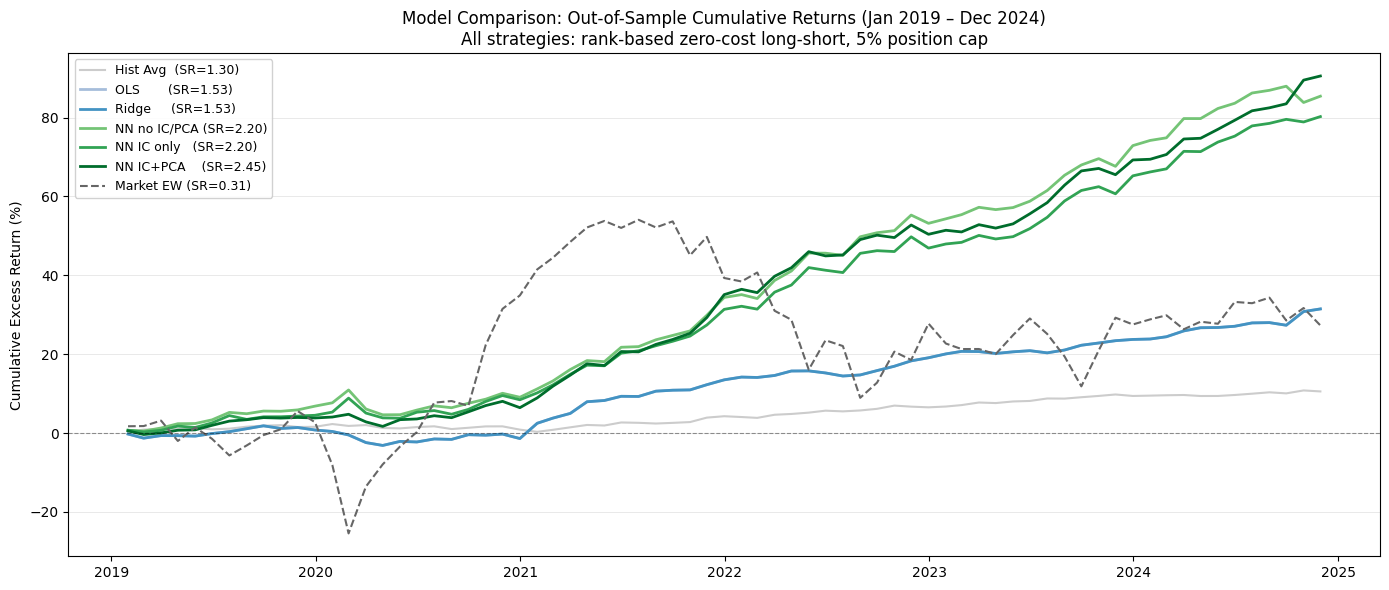

Saved all_models_cumulative.png


In [25]:
# Assemble all return series
all_ret = pd.DataFrame({
    'HistAvg': hist_pf['HistAvg'],
    'OLS'    : ols_pf['OLS'],
    'Ridge'  : ridge_pf['Ridge'],
    'NN_NOPCA' : nn_nopca['pf'][nn_nopca['col']],
    'NN_ICONLY': nn_iconly['pf'][nn_iconly['col']],
    'NN_IC_PCA': nn_main['pf'][nn_main['col']],
    'Market' : ridge_pf['Market'],
})

cum = (1 + all_ret).cumprod() - 1

colors = {
    'HistAvg'  : '#cccccc',
    'OLS'      : '#a6bddb',
    'Ridge'    : '#4393c3',
    'NN_NOPCA' : '#74c476',
    'NN_ICONLY': '#31a354',
    'NN_IC_PCA': '#006d2c',
    'Market'   : '#666666',
}

labels = {
    'HistAvg'  : f'Hist Avg  (SR={hist_sharpe:.2f})',
    'OLS'      : f'OLS       (SR={ols_sharpe:.2f})',
    'Ridge'    : f'Ridge     (SR={ridge_sharpe:.2f})',
    'NN_NOPCA' : f'NN no IC/PCA (SR={nn_nopca["sharpe"]:.2f})',
    'NN_ICONLY': f'NN IC only   (SR={nn_iconly["sharpe"]:.2f})',
    'NN_IC_PCA': f'NN IC+PCA    (SR={nn_main["sharpe"]:.2f})',
    'Market'   : f'Market EW (SR={ridge_pf["Market"].mean()*12/(ridge_pf["Market"].std()*np.sqrt(12)):.2f})',
}

fig, ax = plt.subplots(figsize=(14, 6))
for col in cum.columns:
    ls = '--' if col == 'Market' else '-'
    lw = 1.5 if col in ('Market', 'HistAvg') else 2.0
    ax.plot(cum.index, cum[col] * 100,
            color=colors.get(col, '#333333'),
            linestyle=ls, lw=lw, label=labels.get(col, col))

ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylabel('Cumulative Excess Return (%)')
ax.set_title('Model Comparison: Out-of-Sample Cumulative Returns (Jan 2019 – Dec 2024)\n'
             'All strategies: rank-based zero-cost long-short, 5% position cap')
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)
ax.grid(axis='y', lw=0.4, alpha=0.5)
fig.tight_layout()
plt.savefig('./all_models_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved all_models_cumulative.png')

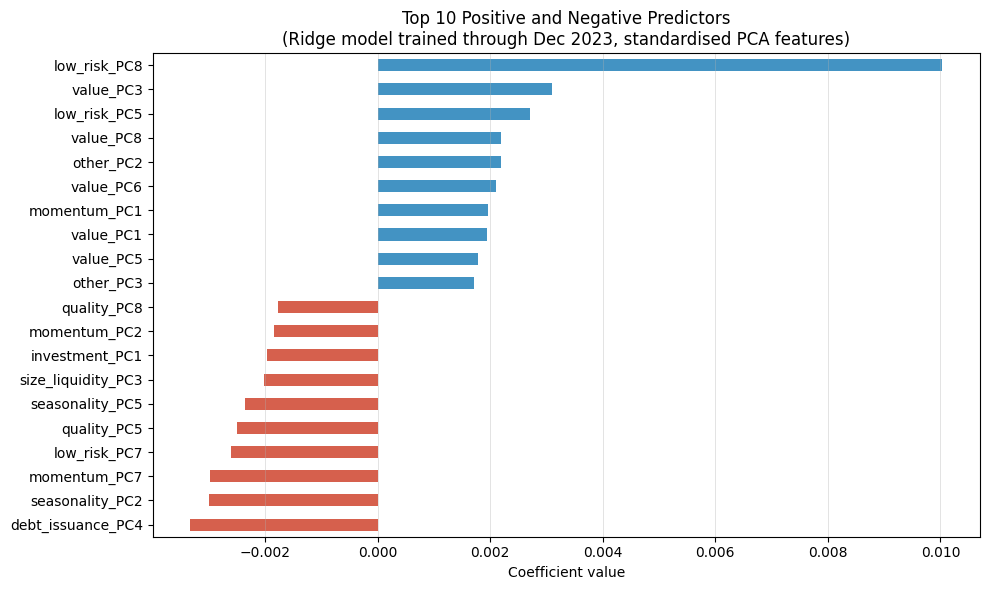

Saved ridge_feature_importance.png


In [27]:
# Ridge feature importance — coefficients from the final walk-forward step (trained through 2023)
coefs = pd.Series(ridge.coef_, index=gpca.output_names)
top_features = pd.concat([coefs.nlargest(10), coefs.nsmallest(10)]).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#d6604d' if c < 0 else '#4393c3' for c in top_features.values]
top_features.plot(kind='barh', color=colors_bar, ax=ax)
ax.set_title('Top 10 Positive and Negative Predictors\n(Ridge model trained through Dec 2023, standardised PCA features)')
ax.set_xlabel('Coefficient value')
ax.grid(axis='x', lw=0.5, alpha=0.5)
fig.tight_layout()
plt.savefig('./ridge_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ridge_feature_importance.png')